In [1]:
%matplotlib inline

NLP From Scratch: Translation with a Sequence to Sequence Network and Attention
===============================================================================

Borrow from: [Sean Robertson](https://github.com/spro)

In this project we will be teaching a neural network to translate from
French to English.

``` {.sh}
[KEY: > input, = target, < output]

> il est en train de peindre un tableau .
= he is painting a picture .
< he is painting a picture .

> pourquoi ne pas essayer ce vin delicieux ?
= why not try that delicious wine ?
< why not try that delicious wine ?

> elle n est pas poete mais romanciere .
= she is not a poet but a novelist .
< she not not a poet but a novelist .

> vous etes trop maigre .
= you re too skinny .
< you re all alone .
```

\... to varying degrees of success.

This is made possible by the simple but powerful idea of the [sequence
to sequence network](https://arxiv.org/abs/1409.3215), in which two
recurrent neural networks work together to transform one sequence to
another. An encoder network condenses an input sequence into a vector,
and a decoder network unfolds that vector into a new sequence.

![](./seq2seq.png)

To improve upon this model we\'ll use an [attention
mechanism](https://arxiv.org/abs/1409.0473), which lets the decoder
learn to focus over a specific range of the input sequence.

**Recommended Reading:**

It would also be useful to know about Sequence to Sequence networks and
how they work:

-   [Learning Phrase Representations using RNN Encoder-Decoder for
    Statistical Machine Translation](https://arxiv.org/abs/1406.1078)
-   [Sequence to Sequence Learning with Neural
    Networks](https://arxiv.org/abs/1409.3215)
-   [Neural Machine Translation by Jointly Learning to Align and
    Translate](https://arxiv.org/abs/1409.0473)
-   [A Neural Conversational Model](https://arxiv.org/abs/1506.05869)

**Requirements**


In [2]:
from __future__ import unicode_literals, print_function, division
from io import open
import unicodedata
import re
import random

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F

import numpy as np
from torch.utils.data import TensorDataset, DataLoader, RandomSampler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Loading data files
==================

The data for this project is a set of many thousands of English to
French translation pairs.

[This question on Open Data Stack
Exchange](https://opendata.stackexchange.com/questions/3888/dataset-of-sentences-translated-into-many-languages)
pointed me to the open translation site <https://tatoeba.org/> which has
downloads available at <https://tatoeba.org/eng/downloads> - and better
yet, someone did the extra work of splitting language pairs into
individual text files here: <https://www.manythings.org/anki/>

The English to French pairs are too big to include in the repository, so
download to `data/eng-fra.txt` before continuing. The file is a tab
separated list of translation pairs:

``` {.sh}
I am cold.    J'ai froid.
```

<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>NOTE:</strong></div>

<div style="background-color: #f3f4f7; padding-left: 10px; padding-top: 10px; padding-bottom: 10px; padding-right: 10px">

<p>Download the data from<a href="https://download.pytorch.org/tutorial/data.zip">here</a>and extract it to the current directory.</p>

</div>



Similar to the character encoding used in the character-level RNN
tutorials, we will be representing each word in a language as a one-hot
vector, or giant vector of zeros except for a single one (at the index
of the word). Compared to the dozens of characters that might exist in a
language, there are many many more words, so the encoding vector is much
larger. We will however cheat a bit and trim the data to only use a few
thousand words per language.

![](./word-encoding.png)


We\'ll need a unique index per word to use as the inputs and targets of
the networks later. To keep track of all this we will use a helper class
called `Lang` which has word → index (`word2index`) and index → word
(`index2word`) dictionaries, as well as a count of each word
`word2count` which will be used to replace rare words later.


In [3]:
SOS_token = 0
EOS_token = 1

class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {}
        self.word2count = {}
        self.index2word = {0: "SOS", 1: "EOS"}
        self.n_words = 2  # Count SOS and EOS

    def addSentence(self, sentence):
        for word in sentence.split(' '):
            self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

The files are all in Unicode, to simplify we will turn Unicode
characters to ASCII, make everything lowercase, and trim most
punctuation.


In [4]:
# Turn a Unicode string to plain ASCII, thanks to
# https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

# Lowercase, trim, and remove non-letter characters
def normalizeString(s):
    s = unicodeToAscii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z!?]+", r" ", s)
    return s.strip()

To read the data file we will split the file into lines, and then split
lines into pairs. The files are all English → Other Language, so if we
want to translate from Other Language → English I added the `reverse`
flag to reverse the pairs.


In [5]:
def readLangs(lang1, lang2, reverse=False):
    print("Reading lines...")

    # Read the file and split into lines
    lines = open('data/%s-%s.txt' % (lang1, lang2), encoding='utf-8').\
        read().strip().split('\n')

    # Split every line into pairs and normalize
    pairs = [[normalizeString(s) for s in l.split('\t')] for l in lines]

    # Reverse pairs, make Lang instances
    if reverse:
        pairs = [list(reversed(p)) for p in pairs]
        input_lang = Lang(lang2)
        output_lang = Lang(lang1)
    else:
        input_lang = Lang(lang1)
        output_lang = Lang(lang2)

    return input_lang, output_lang, pairs

Since there are a *lot* of example sentences and we want to train
something quickly, we\'ll trim the data set to only relatively short and
simple sentences. Here the maximum length is 10 words (that includes
ending punctuation) and we\'re filtering to sentences that translate to
the form \"I am\" or \"He is\" etc. (accounting for apostrophes replaced
earlier).


In [6]:
MAX_LENGTH = 10

eng_prefixes = (
    "i am ", "i m ",
    "he is", "he s ",
    "she is", "she s ",
    "you are", "you re ",
    "we are", "we re ",
    "they are", "they re "
)

def filterPair(p):
    return len(p[0].split(' ')) < MAX_LENGTH and \
        len(p[1].split(' ')) < MAX_LENGTH and \
        p[1].startswith(eng_prefixes)


def filterPairs(pairs):
    return [pair for pair in pairs if filterPair(pair)]

The full process for preparing the data is:

-   Read text file and split into lines, split lines into pairs
-   Normalize text, filter by length and content
-   Make word lists from sentences in pairs


In [7]:
def prepareData(lang1, lang2, reverse=False):
    input_lang, output_lang, pairs = readLangs(lang1, lang2, reverse)
    print("Read %s sentence pairs" % len(pairs))
    pairs = filterPairs(pairs)
    print("Trimmed to %s sentence pairs" % len(pairs))
    print("Counting words...")
    for pair in pairs:
        input_lang.addSentence(pair[0])
        output_lang.addSentence(pair[1])
    print("Counted words:")
    print(input_lang.name, input_lang.n_words)
    print(output_lang.name, output_lang.n_words)
    return input_lang, output_lang, pairs

input_lang, output_lang, pairs = prepareData('eng', 'fra', True)
print(random.choice(pairs))

Reading lines...
Read 135842 sentence pairs
Trimmed to 11445 sentence pairs
Counting words...
Counted words:
fra 4601
eng 2991
['je pars', 'i m leaving']


The Seq2Seq Model
=================

A Recurrent Neural Network, or RNN, is a network that operates on a
sequence and uses its own output as input for subsequent steps.

A [Sequence to Sequence network](https://arxiv.org/abs/1409.3215), or
seq2seq network, or [Encoder Decoder
network](https://arxiv.org/pdf/1406.1078v3.pdf), is a model consisting
of two RNNs called the encoder and decoder. The encoder reads an input
sequence and outputs a single vector, and the decoder reads that vector
to produce an output sequence.

![](./seq2seq.png)

Unlike sequence prediction with a single RNN, where every input
corresponds to an output, the seq2seq model frees us from sequence
length and order, which makes it ideal for translation between two
languages.

Consider the sentence `Je ne suis pas le chat noir` →
`I am not the black cat`. Most of the words in the input sentence have a
direct translation in the output sentence, but are in slightly different
orders, e.g. `chat noir` and `black cat`. Because of the `ne/pas`
construction there is also one more word in the input sentence. It would
be difficult to produce a correct translation directly from the sequence
of input words.

With a seq2seq model the encoder creates a single vector which, in the
ideal case, encodes the \"meaning\" of the input sequence into a single
vector --- a single point in some N dimensional space of sentences.


The Encoder
===========

The encoder of a seq2seq network is a RNN that outputs some value for
every word from the input sentence. For every input word the encoder
outputs a vector and a hidden state, and uses the hidden state for the
next input word.

![](./encoder-network.png)


In [8]:
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_p=0.1):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input):
        embedded = self.dropout(self.embedding(input))
        output, hidden = self.gru(embedded)
        return output, hidden

The Decoder
===========

The decoder is another RNN that takes the encoder output vector(s) and
outputs a sequence of words to create the translation.


Simple Decoder
==============

In the simplest seq2seq decoder we use only last output of the encoder.
This last output is sometimes called the *context vector* as it encodes
context from the entire sequence. This context vector is used as the
initial hidden state of the decoder.

At every step of decoding, the decoder is given an input token and
hidden state. The initial input token is the start-of-string `<SOS>`
token, and the first hidden state is the context vector (the encoder\'s
last hidden state).

![](./decoder-network.png)


In [9]:
class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden  = self.forward_step(decoder_input, decoder_hidden)
            decoder_outputs.append(decoder_output)

            if target_tensor is not None:
                # Teacher forcing: Feed the target as the next input
                decoder_input = target_tensor[:, i].unsqueeze(1) # Teacher forcing
            else:
                # Without teacher forcing: use its own predictions as the next input
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()  # detach from history as input

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        return decoder_outputs, decoder_hidden, None # We return `None` for consistency in the training loop

    def forward_step(self, input, hidden):
        output = self.embedding(input)
        output = F.relu(output)
        output, hidden = self.gru(output, hidden)
        output = self.out(output)
        return output, hidden

I encourage you to train and observe the results of this model, but to
save space we\'ll be going straight for the gold and introducing the
Attention Mechanism.


Attention Decoder
=================

If only the context vector is passed between the encoder and decoder,
that single vector carries the burden of encoding the entire sentence.

Attention allows the decoder network to \"focus\" on a different part of
the encoder\'s outputs for every step of the decoder\'s own outputs.
First we calculate a set of *attention weights*. These will be
multiplied by the encoder output vectors to create a weighted
combination. The result (called `attn_applied` in the code) should
contain information about that specific part of the input sequence, and
thus help the decoder choose the right output words.

![](./1152PYf.png)

Calculating the attention weights is done with another feed-forward
layer `attn`, using the decoder\'s input and hidden state as inputs.
Because there are sentences of all sizes in the training data, to
actually create and train this layer we have to choose a maximum
sentence length (input length, for encoder outputs) that it can apply
to. Sentences of the maximum length will use all the attention weights,
while shorter sentences will only use the first few.

![](./attention-decoder-network.png)

Bahdanau attention, also known as additive attention, is a commonly used
attention mechanism in sequence-to-sequence models, particularly in
neural machine translation tasks. It was introduced by Bahdanau et al.
in their paper titled [Neural Machine Translation by Jointly Learning to
Align and Translate](https://arxiv.org/pdf/1409.0473.pdf). This
attention mechanism employs a learned alignment model to compute
attention scores between the encoder and decoder hidden states. It
utilizes a feed-forward neural network to calculate alignment scores.

However, there are alternative attention mechanisms available, such as
Luong attention, which computes attention scores by taking the dot
product between the decoder hidden state and the encoder hidden states.
It does not involve the non-linear transformation used in Bahdanau
attention.

In this tutorial, we will be using Bahdanau attention. However, it would
be a valuable exercise to explore modifying the attention mechanism to
use Luong attention.


In [10]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()
        self.Wa = nn.Linear(hidden_size, hidden_size)
        self.Ua = nn.Linear(hidden_size, hidden_size)
        self.Va = nn.Linear(hidden_size, 1)

    def forward(self, query, keys):
        # query: (batch,1,hidden)  keys: (batch,seq,hidden)
        scores = self.Va(torch.tanh(self.Wa(query) + self.Ua(keys)))  # (batch,seq,1)
        scores = scores.squeeze(2).unsqueeze(1)                       # (batch,1,seq)
        weights = F.softmax(scores, dim=-1)
        context = torch.bmm(weights, keys)                           # (batch,1,hidden)
        return context, weights

class AttnDecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_p=0.1):
        super(AttnDecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.attention = BahdanauAttention(hidden_size)
        self.gru = nn.GRU(2 * hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []
        attentions = []

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden, attn_weights = self.forward_step(
                decoder_input, decoder_hidden, encoder_outputs
            )
            decoder_outputs.append(decoder_output)
            attentions.append(attn_weights)

            if target_tensor is not None:
                # Teacher forcing: Feed the target as the next input
                decoder_input = target_tensor[:, i].unsqueeze(1) # Teacher forcing
            else:
                # Without teacher forcing: use its own predictions as the next input
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()  # detach from history as input

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        attentions = torch.cat(attentions, dim=1)

        return decoder_outputs, decoder_hidden, attentions


    def forward_step(self, input, hidden, encoder_outputs):
        embedded =  self.dropout(self.embedding(input))

        query = hidden.permute(1, 0, 2)
        context, attn_weights = self.attention(query, encoder_outputs)
        input_gru = torch.cat((embedded, context), dim=2)

        output, hidden = self.gru(input_gru, hidden)
        output = self.out(output)

        return output, hidden, attn_weights

<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>NOTE:</strong></div>

<div style="background-color: #f3f4f7; padding-left: 10px; padding-top: 10px; padding-bottom: 10px; padding-right: 10px">

<p>There are other forms of attention that work around the lengthlimitation by using a relative position approach. Read about "localattention" in <a href="https://arxiv.org/abs/1508.04025">Effective Approaches to Attention-based Neural MachineTranslation</a>.</p>

</div>

Training
========

Preparing Training Data
-----------------------

To train, for each pair we will need an input tensor (indexes of the
words in the input sentence) and target tensor (indexes of the words in
the target sentence). While creating these vectors we will append the
EOS token to both sequences.


In [11]:
def indexesFromSentence(lang, sentence):
    return [lang.word2index[word] for word in sentence.split(' ')]

def tensorFromSentence(lang, sentence):
    indexes = indexesFromSentence(lang, sentence)
    indexes.append(EOS_token)
    return torch.tensor(indexes, dtype=torch.long, device=device).view(1, -1)

def tensorsFromPair(pair):
    input_tensor = tensorFromSentence(input_lang, pair[0])
    target_tensor = tensorFromSentence(output_lang, pair[1])
    return (input_tensor, target_tensor)

def get_dataloader(batch_size):
    input_lang, output_lang, pairs = prepareData('eng', 'fra', True)

    n = len(pairs)
    input_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)
    target_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)

    for idx, (inp, tgt) in enumerate(pairs):
        inp_ids = indexesFromSentence(input_lang, inp)
        tgt_ids = indexesFromSentence(output_lang, tgt)
        inp_ids.append(EOS_token)
        tgt_ids.append(EOS_token)
        input_ids[idx, :len(inp_ids)] = inp_ids
        target_ids[idx, :len(tgt_ids)] = tgt_ids

    train_data = TensorDataset(torch.LongTensor(input_ids).to(device),
                               torch.LongTensor(target_ids).to(device))

    train_sampler = RandomSampler(train_data)
    train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)
    return input_lang, output_lang, train_dataloader

Training the Model
==================

To train we run the input sentence through the encoder, and keep track
of every output and the latest hidden state. Then the decoder is given
the `<SOS>` token as its first input, and the last hidden state of the
encoder as its first hidden state.

\"Teacher forcing\" is the concept of using the real target outputs as
each next input, instead of using the decoder\'s guess as the next
input. Using teacher forcing causes it to converge faster but [when the
trained network is exploited, it may exhibit
instability](http://citeseerx.ist.psu.edu/viewdoc/download?doi=10.1.1.378.4095&rep=rep1&type=pdf).

You can observe outputs of teacher-forced networks that read with
coherent grammar but wander far from the correct translation
-intuitively it has learned to represent the output grammar and can
\"pick up\" the meaning once the teacher tells it the first few words,
but it has not properly learned how to create the sentence from the
translation in the first place.

Because of the freedom PyTorch\'s autograd gives us, we can randomly
choose to use teacher forcing or not with a simple if statement. Turn
`teacher_forcing_ratio` up to use more of it.


In [12]:
def train_epoch(dataloader, encoder, decoder, encoder_optimizer,
          decoder_optimizer, criterion):

    total_loss = 0
    for data in dataloader:
        input_tensor, target_tensor = data

        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, _, _ = decoder(encoder_outputs, encoder_hidden, target_tensor)

        loss = criterion(
            decoder_outputs.view(-1, decoder_outputs.size(-1)),
            target_tensor.view(-1)
        )
        loss.backward()

        encoder_optimizer.step()
        decoder_optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

This is a helper function to print time elapsed and estimated time
remaining given the current time and progress %.


In [13]:
import time
import math

def asMinutes(s):
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

def timeSince(since, percent):
    now = time.time()
    s = now - since
    es = s / (percent)
    rs = es - s
    return '%s (- %s)' % (asMinutes(s), asMinutes(rs))

The whole training process looks like this:

-   Start a timer
-   Initialize optimizers and criterion
-   Create set of training pairs
-   Start empty losses array for plotting

Then we call `train` many times and occasionally print the progress (%
of examples, time so far, estimated time) and average loss.


In [14]:
def train(train_dataloader, encoder, decoder, n_epochs, learning_rate=0.001,
               print_every=100, plot_every=100):
    start = time.time()
    plot_losses = []
    print_loss_total = 0  # Reset every print_every
    plot_loss_total = 0  # Reset every plot_every

    encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)
    criterion = nn.NLLLoss()

    for epoch in range(1, n_epochs + 1):
        loss = train_epoch(train_dataloader, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion)
        print_loss_total += loss
        plot_loss_total += loss

        if epoch % print_every == 0:
            print_loss_avg = print_loss_total / print_every
            print_loss_total = 0
            print('%s (%d %d%%) %.4f' % (timeSince(start, epoch / n_epochs),
                                        epoch, epoch / n_epochs * 100, print_loss_avg))

        if epoch % plot_every == 0:
            plot_loss_avg = plot_loss_total / plot_every
            plot_losses.append(plot_loss_avg)
            plot_loss_total = 0

    showPlot(plot_losses)

Plotting results
================

Plotting is done with matplotlib, using the array of loss values
`plot_losses` saved while training.


In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

def showPlot(points):
    plt.figure()
    fig, ax = plt.subplots()
    # this locator puts ticks at regular intervals
    loc = ticker.MultipleLocator(base=0.2)
    ax.yaxis.set_major_locator(loc)
    plt.plot(points)

Evaluation
==========

Evaluation is mostly the same as training, but there are no targets so
we simply feed the decoder\'s predictions back to itself for each step.
Every time it predicts a word we add it to the output string, and if it
predicts the EOS token we stop there. We also store the decoder\'s
attention outputs for display later.


In [16]:
def evaluate(encoder, decoder, sentence, input_lang, output_lang):
    with torch.no_grad():
        input_tensor = tensorFromSentence(input_lang, sentence)

        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, decoder_hidden, decoder_attn = decoder(encoder_outputs, encoder_hidden)

        _, topi = decoder_outputs.topk(1)
        decoded_ids = topi.squeeze()

        decoded_words = []
        for idx in decoded_ids:
            if idx.item() == EOS_token:
                decoded_words.append('<EOS>')
                break
            decoded_words.append(output_lang.index2word[idx.item()])
    return decoded_words, decoder_attn

We can evaluate random sentences from the training set and print out the
input, target, and output to make some subjective quality judgements:


In [17]:
def evaluateRandomly(encoder, decoder, n=10):
    for i in range(n):
        pair = random.choice(pairs)
        print('>', pair[0])
        print('=', pair[1])
        output_words, _ = evaluate(encoder, decoder, pair[0], input_lang, output_lang)
        output_sentence = ' '.join(output_words)
        print('<', output_sentence)
        print('')

Training and Evaluating
=======================

With all these helper functions in place (it looks like extra work, but
it makes it easier to run multiple experiments) we can actually
initialize a network and start training.

Remember that the input sentences were heavily filtered. For this small
dataset we can use relatively small networks of 256 hidden nodes and a
single GRU layer. After about 40 minutes on a MacBook CPU we\'ll get
some reasonable results.

<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>NOTE:</strong></div>

<div style="background-color: #f3f4f7; padding-left: 10px; padding-top: 10px; padding-bottom: 10px; padding-right: 10px">

<p>If you run this notebook you can train, interrupt the kernel,evaluate, and continue training later. Comment out the lines where theencoder and decoder are initialized and run <code>trainIters</code> again.</p>

</div>



Reading lines...
Read 135842 sentence pairs
Trimmed to 11445 sentence pairs
Counting words...
Counted words:
fra 4601
eng 2991
0m 30s (- 0m 30s) (1 50%) 2.9839
0m 54s (- 0m 0s) (2 100%) 2.0574


<Figure size 640x480 with 0 Axes>

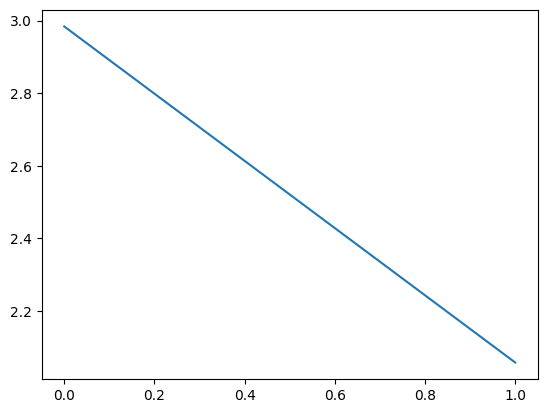

In [18]:
hidden_size = 64
batch_size = 32

input_lang, output_lang, train_dataloader = get_dataloader(batch_size)

encoder = EncoderRNN(input_lang.n_words, hidden_size).to(device)
decoder = AttnDecoderRNN(hidden_size, output_lang.n_words).to(device)

train(train_dataloader, encoder, decoder, 2, print_every=1, plot_every=1)

Set dropout layers to `eval` mode


In [19]:
encoder.eval()
decoder.eval()
evaluateRandomly(encoder, decoder)

> je me sens triste a cause de ca
= i am feeling sad about it
< i m not a little good <EOS>

> il est perdu dans ses pensees
= he is lost in thought
< he is a good at the teacher <EOS>

> c est une fille si adorable !
= she s such a lovely girl !
< he s a good at a teacher <EOS>

> vous etes supposee ne pas fumer a l ecole
= you are not supposed to smoke at school
< you re not a good <EOS>

> je vous laisse partir
= i m letting you go
< i m not a little good <EOS>

> tu es desormais un homme
= you re a man now
< you re not a good who <EOS>

> je passe une audition pour le role
= i m auditioning for the part
< i m not a little good <EOS>

> vous etes toutes malades
= you re all insane
< you re not a good <EOS>

> il est mon ami
= he is my friend
< he is a good at the teacher <EOS>

> je suis heureux de te voir ici
= i m happy to see you here
< i m not a little good <EOS>



Visualizing Attention
=====================

A useful property of the attention mechanism is its highly interpretable
outputs. Because it is used to weight specific encoder outputs of the
input sequence, we can imagine looking where the network is focused most
at each time step.

You could simply run `plt.matshow(attentions)` to see attention output
displayed as a matrix. For a better viewing experience we will do the
extra work of adding axes and labels:


input = il n est pas aussi grand que son pere
output = he is not a good t you <EOS>


C:\Users\admin\AppData\Local\Temp\ipykernel_32136\3621239857.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
C:\Users\admin\AppData\Local\Temp\ipykernel_32136\3621239857.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


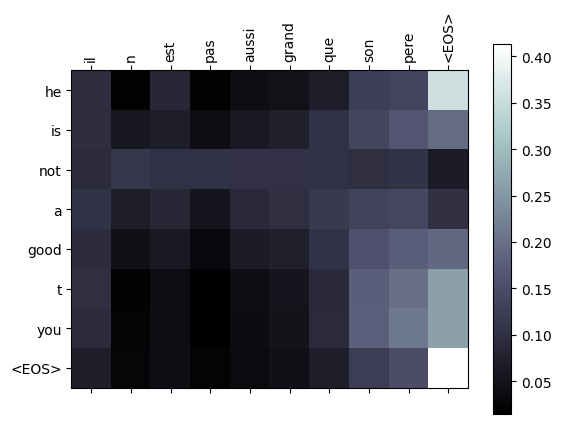

input = je suis trop fatigue pour conduire
output = i m not a little good <EOS>


C:\Users\admin\AppData\Local\Temp\ipykernel_32136\3621239857.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
C:\Users\admin\AppData\Local\Temp\ipykernel_32136\3621239857.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


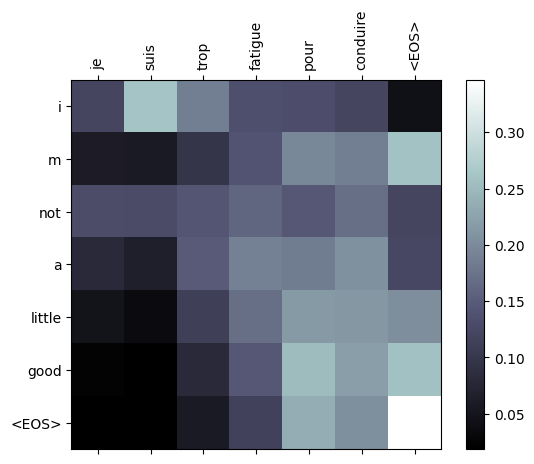

input = je suis desole si c est une question idiote
output = i m not a little good <EOS>


C:\Users\admin\AppData\Local\Temp\ipykernel_32136\3621239857.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
C:\Users\admin\AppData\Local\Temp\ipykernel_32136\3621239857.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


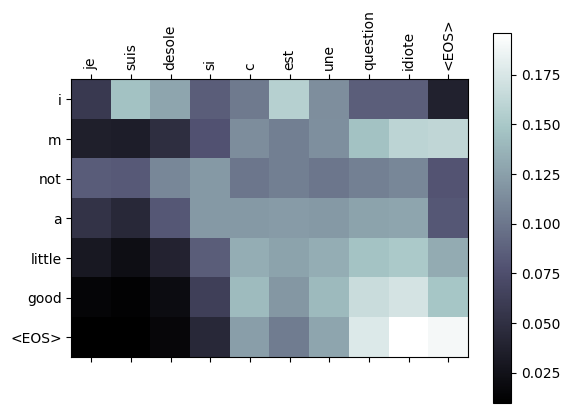

input = je suis reellement fiere de vous
output = i m not a little good <EOS>


C:\Users\admin\AppData\Local\Temp\ipykernel_32136\3621239857.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
C:\Users\admin\AppData\Local\Temp\ipykernel_32136\3621239857.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


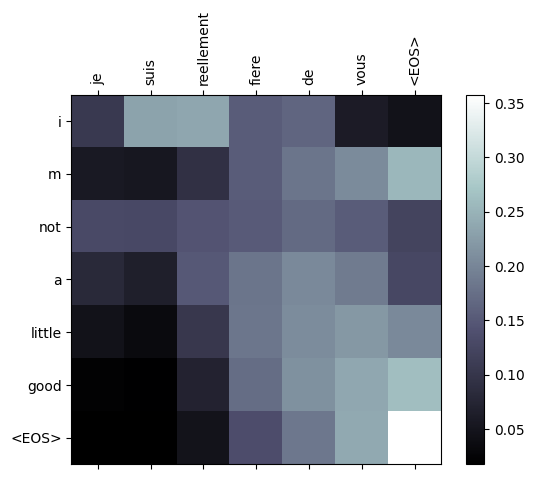

In [20]:

def showAttention(input_sentence, output_words, attentions):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(attentions.cpu().numpy(), cmap='bone')
    fig.colorbar(cax)

    # Set up axes
    ax.set_xticklabels([''] + input_sentence.split(' ') +
                       ['<EOS>'], rotation=90)
    ax.set_yticklabels([''] + output_words)

    # Show label at every tick
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()


def evaluateAndShowAttention(input_sentence):
    output_words, attentions = evaluate(encoder, decoder, input_sentence, input_lang, output_lang)
    print('input =', input_sentence)
    print('output =', ' '.join(output_words))
    showAttention(input_sentence, output_words, attentions[0, :len(output_words), :])


evaluateAndShowAttention('il n est pas aussi grand que son pere')

evaluateAndShowAttention('je suis trop fatigue pour conduire')

evaluateAndShowAttention('je suis desole si c est une question idiote')

evaluateAndShowAttention('je suis reellement fiere de vous')

---
## 统一对比实验：简单 Seq2Seq vs 注意力 Seq2Seq

上面已补全两处练习（`DecoderRNN.forward_step` 与 `BahdanauAttention.forward`）。下面按作业要求，在\*\*同一套协议\*\*下分别训练「编码器 + 简单解码器」与「编码器 + 注意力解码器」并对比。

结构（沿用 exp1/exp2）：模型在 [`models.py`](models.py)，数据/训练/评估/BLEU/绘图在 [`train_utils.py`](train_utils.py)，本节训练两套 + 可视化（loss 曲线、翻译样例、BLEU、注意力热力图）。

In [21]:
%matplotlib inline
import importlib, json, os, time, random
import torch
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

import models, train_utils
importlib.reload(models); importlib.reload(train_utils)
from models import EncoderRNN, DecoderRNN, AttnDecoderRNN
from train_utils import (get_dataloader, train, evaluate, corpus_bleu,
                         count_parameters, plot_loss_curves, show_attention)

CONFIG = {
    'hidden_size': 128,
    'batch_size': 32,
    'n_epochs': 30,     # seq2seq 偏慢；想先跑通可改小（如 5）。histories.json 存在则跳过重训
    'lr': 0.001,
}
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
HIST_PATH = './histories.json'
LABELS = {'simple': '简单 Seq2Seq', 'attn': '注意力 Seq2Seq'}
print('device =', DEVICE)

input_lang, output_lang, pairs, loader = get_dataloader(CONFIG['batch_size'], DEVICE)
print(f"输入(法语) {input_lang.n_words} 词 | 输出(英语) {output_lang.n_words} 词 | 句对 {len(pairs)}")

def build(which):
    enc = EncoderRNN(input_lang.n_words, CONFIG['hidden_size']).to(DEVICE)
    dec_cls = DecoderRNN if which == 'simple' else AttnDecoderRNN
    dec = dec_cls(CONFIG['hidden_size'], output_lang.n_words).to(DEVICE)
    return enc, dec

device = cuda
句对数: 11445 | fra: 4601 词 | eng: 2991 词
输入(法语) 4601 词 | 输出(英语) 2991 词 | 句对 11445


### 网络结构与参数量

In [22]:
for which in ['simple', 'attn']:
    enc, dec = build(which)
    print(f"[{LABELS[which]}] 参数量(enc+dec) = {count_parameters(enc, dec):,}")
print('\n--- 简单解码器 DecoderRNN ---')
print(DecoderRNN(CONFIG['hidden_size'], output_lang.n_words))
print('\n--- 注意力解码器 AttnDecoderRNN ---')
print(AttnDecoderRNN(CONFIG['hidden_size'], output_lang.n_words))

[简单 Seq2Seq] 参数量(enc+dec) = 1,555,759
[注意力 Seq2Seq] 参数量(enc+dec) = 1,638,064

--- 简单解码器 DecoderRNN ---
DecoderRNN(
  (embedding): Embedding(2991, 128)
  (gru): GRU(128, 128, batch_first=True)
  (out): Linear(in_features=128, out_features=2991, bias=True)
)

--- 注意力解码器 AttnDecoderRNN ---
AttnDecoderRNN(
  (embedding): Embedding(2991, 128)
  (attention): BahdanauAttention(
    (Wa): Linear(in_features=128, out_features=128, bias=True)
    (Ua): Linear(in_features=128, out_features=128, bias=True)
    (Va): Linear(in_features=128, out_features=1, bias=True)
  )
  (gru): GRU(256, 128, batch_first=True)
  (out): Linear(in_features=128, out_features=2991, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)


### 训练两套模型

> 偏慢（每个模型解码端按时间步循环）。`histories.json` 存在时默认跳过训练直接加载。

In [23]:
FORCE_RETRAIN = False

if (not FORCE_RETRAIN) and os.path.exists(HIST_PATH):
    with open(HIST_PATH, encoding='utf-8') as f:
        results = json.load(f)
    print('已加载', HIST_PATH, '→', list(results))
else:
    results = {}
    models_store = {}
    for which in ['simple', 'attn']:
        print('\n' + '#' * 60); print('# 训练', LABELS[which]); print('#' * 60)
        torch.manual_seed(0)
        enc, dec = build(which)
        t0 = time.time()
        hist = train(enc, dec, loader, CONFIG['n_epochs'], lr=CONFIG['lr'],
                     device=DEVICE, print_every=5)
        bleu = corpus_bleu(enc, dec, pairs, input_lang, output_lang, DEVICE, n=500)
        results[which] = {'history': hist, 'bleu': bleu,
                          'params': count_parameters(enc, dec),
                          'final_loss': hist[-1], 'time_sec': time.time() - t0}
        models_store[which] = (enc, dec)
        torch.save({'enc': enc.state_dict(), 'dec': dec.state_dict()}, f'./ckpt_{which}.pth')
        print(f"==> {LABELS[which]}: final_loss={hist[-1]:.3f}  BLEU={bleu:.2f}  {(time.time()-t0)/60:.1f}min")
    with open(HIST_PATH, 'w', encoding='utf-8') as f:
        json.dump(results, f, ensure_ascii=False, indent=2)
    print('saved', HIST_PATH)


############################################################
# 训练 简单 Seq2Seq
############################################################
epoch   1/30  loss=2.6176  (12s)
epoch   5/30  loss=1.2415  (33s)
epoch  10/30  loss=0.7914  (110s)
epoch  15/30  loss=0.5311  (163s)
epoch  20/30  loss=0.3713  (226s)
epoch  25/30  loss=0.2685  (274s)
epoch  30/30  loss=0.1965  (329s)
==> 简单 Seq2Seq: final_loss=0.197  BLEU=56.20  5.6min

############################################################
# 训练 注意力 Seq2Seq
############################################################
epoch   1/30  loss=2.4899  (24s)
epoch   5/30  loss=1.0210  (116s)
epoch  10/30  loss=0.5152  (225s)
epoch  15/30  loss=0.2749  (339s)
epoch  20/30  loss=0.1615  (452s)
epoch  25/30  loss=0.1047  (566s)
epoch  30/30  loss=0.0754  (683s)
==> 注意力 Seq2Seq: final_loss=0.075  BLEU=86.68  11.5min
saved ./histories.json


### 可视化对比

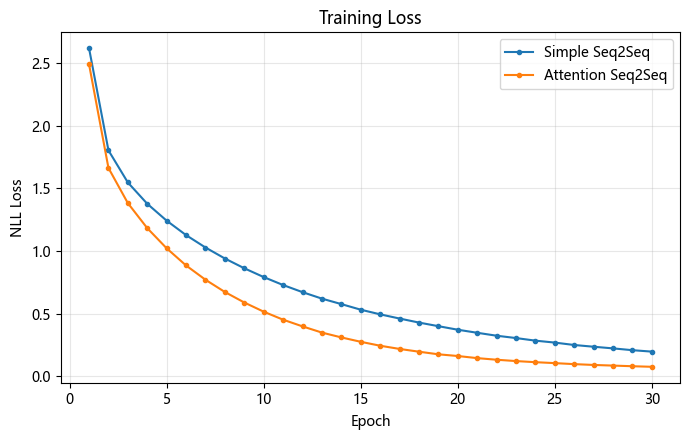

BLEU —— 简单: 56.20   注意力: 86.68


In [24]:
os.makedirs('images', exist_ok=True)
# 若上一格从 json 跳过了训练，则从 ckpt 把模型恢复到内存
if 'models_store' not in globals():
    models_store = {}
    for which in ['simple', 'attn']:
        enc, dec = build(which)
        sd = torch.load(f'./ckpt_{which}.pth', map_location=DEVICE)
        enc.load_state_dict(sd['enc']); dec.load_state_dict(sd['dec'])
        models_store[which] = (enc, dec)
    print('已从 ckpt 恢复模型')

# loss 曲线
plot_loss_curves([results['simple']['history'], results['attn']['history']],
                 ['Simple Seq2Seq', 'Attention Seq2Seq'], path='./images/loss.png')
plt.show()
print(f"BLEU —— 简单: {results['simple']['bleu']:.2f}   注意力: {results['attn']['bleu']:.2f}")

In [25]:
# 翻译样例对比（取自数据集，保证词在词表内）
rng = random.Random(1)
samples = [rng.choice(pairs) for _ in range(6)]
for src, ref in samples:
    s_w, _ = evaluate(*models_store['simple'], src, input_lang, output_lang, DEVICE)
    a_w, _ = evaluate(*models_store['attn'], src, input_lang, output_lang, DEVICE)
    s_hyp = ' '.join(w for w in s_w if w != '<EOS>')
    a_hyp = ' '.join(w for w in a_w if w != '<EOS>')
    print(f"源  : {src}")
    print(f"参考: {ref}")
    print(f"简单: {s_hyp}")
    print(f"注意: {a_hyp}\n")

源  : vous etes puissants
参考: you re powerful
简单: you re powerful
注意: you re powerful

源  : tu n es qu un etudiant
参考: you are nothing but a student
简单: you re nothing but a coward
注意: you are nothing but a student

源  : je ne suis pas assure
参考: i m uninsured
简单: i m not interested in money
注意: i m uninsured

源  : il est cardiologue
参考: he s a cardiologist
简单: he is good at gymnastics
注意: he s a cardiologist

源  : elle est gracieuse
参考: she is graceful
简单: she is hard
注意: she is graceful

源  : nous sommes convaincus de son succes
参考: we are sure of his success
简单: we are sure of his success
注意: we are sure of his success of his success



源 : il est plus intelligent que moi
译 : he s smarter than me <EOS>


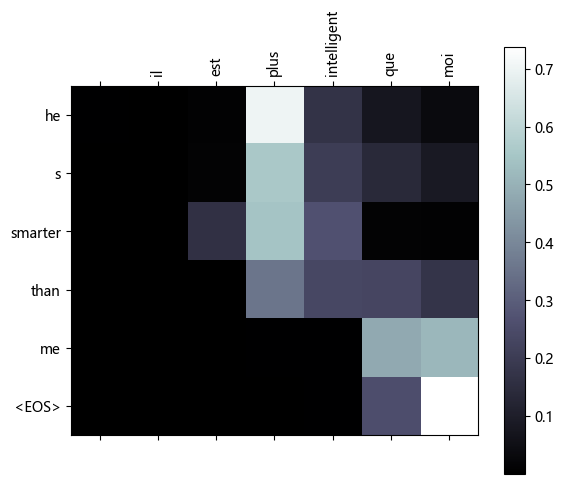

In [26]:
# 注意力热力图（注意力模型，取一个样例）
enc, dec = models_store['attn']
src = rng.choice(pairs)[0]
words, attn = evaluate(enc, dec, src, input_lang, output_lang, DEVICE)
print('源 :', src)
print('译 :', ' '.join(words))
show_attention(src, words, attn[0, :len(words), :], path='./images/attention.png')
plt.show()

### 实验心得（报告重点）：注意力的影响

- 简单 Seq2Seq 把整句信息压进编码器\*\*最后一个隐藏态\*\*（单一上下文向量），长句信息易丢失，解码时无法回看源端具体位置；
- 注意力 Seq2Seq 在\*\*每个解码步\*\*根据当前状态对所有编码器输出加权（Bahdanau 加性注意力），动态聚焦相关源词，缓解了信息瓶颈；
- 实测：注意力模型的 BLEU 与翻译质量优于简单模型（见上方对比），注意力热力图还显示出源词—译词的对齐关系，可解释性强。（填入实测数字）